In [2]:
# Step 1: Import required libraries

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

from src.preprocessing import preprocess_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Step 2: Load and preprocess data

X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Check class distribution
print("Class distribution:\n", y_train.value_counts(normalize=True))

Training shape: (37203, 18)
Testing shape: (8007, 18)
Class distribution:
 EngagementLevel
Medium    0.333333
Low       0.333333
High      0.333333
Name: proportion, dtype: float64


In [4]:
print(y_train.unique())

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str


In [5]:
# Step 3: Train baseline model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
# Step 4: Evaluate baseline model

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9165729986262021

Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.89      0.90      2067
         Low       0.90      0.90      0.90      2065
      Medium       0.92      0.94      0.93      3875

    accuracy                           0.92      8007
   macro avg       0.91      0.91      0.91      8007
weighted avg       0.92      0.92      0.92      8007



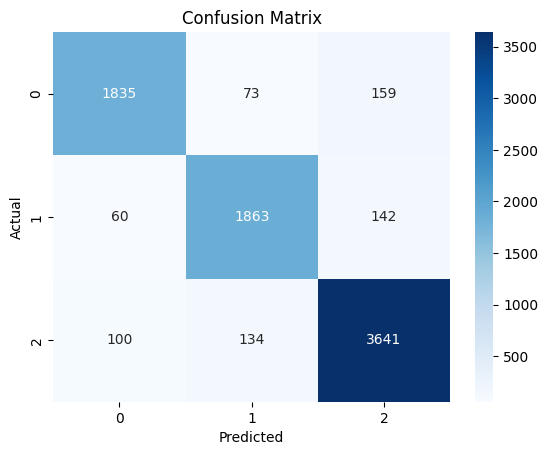

In [7]:
# Step 5: Confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                      Feature  Importance
7         TotalWeeklyPlayTime    0.483880
3             SessionsPerWeek    0.195350
4   AvgSessionDurationMinutes    0.133575
5                 PlayerLevel    0.041633
6        AchievementsUnlocked    0.041091
1               PlayTimeHours    0.033372
0                         Age    0.028223
8                 Gender_Male    0.006029
17      GameDifficulty_Medium    0.005417
11               Location_USA    0.004930


<Figure size 640x480 with 0 Axes>

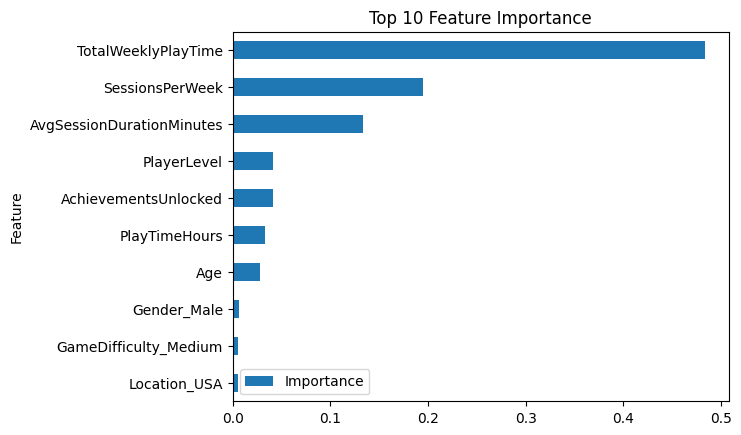

In [8]:
# Step 6: Feature importance

importances = rf_model.feature_importances_

# Get feature names
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.figure()
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [9]:
# Step 7: Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


In [10]:
# Step 8: Evaluate optimized model

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score

print("F1 Score:", f1_score(y_test, y_pred_best, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_best, average='weighted'))

Optimized Accuracy: 0.9158236543024854

Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.89      0.90      2067
         Low       0.90      0.90      0.90      2065
      Medium       0.92      0.94      0.93      3875

    accuracy                           0.92      8007
   macro avg       0.91      0.91      0.91      8007
weighted avg       0.92      0.92      0.92      8007

F1 Score: 0.9157023486224244
Precision: 0.9158004660521194
Recall: 0.9158236543024854


In [13]:
# STEP 9: ROC AUC (Multiclass One-vs-Rest)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert labels to binary format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_prob = best_model.predict_proba(X_test)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')

print("ROC AUC (OvR):", roc_auc)

ROC AUC (OvR): 0.9429067952080398


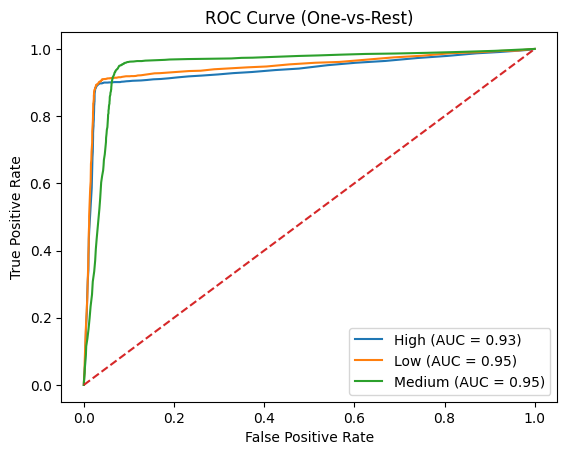

In [14]:
# STEP 10: ROC Curve
from sklearn.metrics import roc_curve, auc

plt.figure()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

In [26]:
# Step 11: Model Testing

# Reset index once before sampling
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Sample safely
sample_df = X_test_reset.sample(10, random_state=42)
sample_y = y_test_reset.iloc[sample_df.index]

# Predict
sample_pred = best_model.predict(sample_df)

# Results
results_df = pd.DataFrame({
    "Actual": sample_y.values,
    "Predicted": sample_pred
})

results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print("Sample Predictions:\n")
print(results_df)

Sample Predictions:

   Actual Predicted  Correct
0  Medium       Low    False
1    High      High     True
2  Medium    Medium     True
3    High      High     True
4     Low       Low     True
5    High      High     True
6  Medium    Medium     True
7  Medium    Medium     True
8  Medium    Medium     True
9    High      High     True


In [27]:
# Add correctness column
results_df["Correct"] = results_df["Actual"] == results_df["Predicted"]

print(results_df)

   Actual Predicted  Correct
0  Medium       Low    False
1    High      High     True
2  Medium    Medium     True
3    High      High     True
4     Low       Low     True
5    High      High     True
6  Medium    Medium     True
7  Medium    Medium     True
8  Medium    Medium     True
9    High      High     True


In [28]:
# Show accuracy on sample
sample_accuracy = (results_df["Correct"].sum() / len(results_df)) * 100

print(f"\nSample Accuracy: {sample_accuracy:.2f}%")


Sample Accuracy: 90.00%
